In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
data_path = r'C:\Users\user\Desktop\연구\7. CATGCN\1. Revision\소방\eda\AI_학습용_동영상'
data_path

'C:\\Users\\user\\Desktop\\연구\\7. CATGCN\\1. Revision\\소방\\eda\\AI_학습용_동영상'

In [3]:
stats = []

for i in range(1, 342):
    folder_name = str(i)
    folder_full_path = os.path.join(data_path, folder_name)

    # print(folder_full_path)
    if os.path.exists(folder_full_path):
        json_files = [f for f in os.listdir(folder_full_path) if f.endswith('.json')]
        count = len(json_files)
        stats.append({'class_id': i,
                      'count': count})
    else:
        print(f"Folder {folder_name} not found.")

In [4]:
df = pd.DataFrame(stats)
df

,class_id,count
0,1,41
1,2,41
2,3,41
3,4,41
4,5,41
...,...,...
336,337,41
337,338,41
338,339,41
339,340,41


In [5]:
# 기초 통계량 출력
print(f"전체 샘플 수: {df['count'].sum()}")
print(f"클래스별 평균 샘플 수: {df['count'].mean():.2f}")
print(f"최소 샘플 수: {df['count'].min()}")
print(f"최대 샘플 수: {df['count'].max()}")
print(f"표준 편차: {df['count'].std():.2f}")

전체 샘플 수: 13981
클래스별 평균 샘플 수: 41.00
최소 샘플 수: 41
최대 샘플 수: 41
표준 편차: 0.00


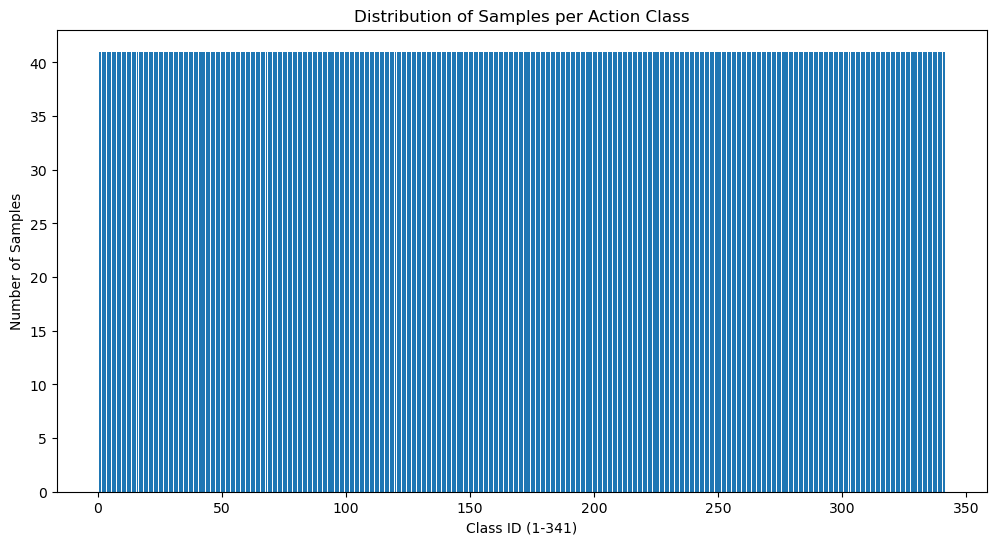

In [7]:
# 분포 시각화 (리뷰어에게 제출할 자료용)
plt.figure(figsize=(12, 6))
plt.bar(df['class_id'], df['count'])
plt.title('Distribution of Samples per Action Class')
plt.xlabel('Class ID (1-341)')
plt.ylabel('Number of Samples')
plt.show()

In [25]:
data_path
fd_name = [name for name in os.listdir(data_path) if name != '.DS_Store']
frame_counts = []

for ifd in fd_name:
    folder = os.path.join(data_path, ifd)
    fname = sorted([x for x in os.listdir(folder) if x.lower().endswith('.json')])

    for ifn in fname:
        file_path = os.path.join(folder, ifn)

        with open(file_path, 'r', encoding='utf-8') as f:
            json_object = json.load(f)
            nframe = json_object['animations']['total_frame']
            frame_counts.append(nframe)

frame_counts = np.array(frame_counts)
total = len(frame_counts)

print(f"Total samples: {total}")
print(f">= 300 frames: {(frame_counts >= 300).sum()} ({(frame_counts >= 300).mean()*100:.1f}%)")
print(f"250-299 frames: {((frame_counts >= 250) & (frame_counts < 300)).sum()} ({((frame_counts >= 250) & (frame_counts < 300)).mean()*100:.1f}%)")
print(f"200-249 frames: {((frame_counts >= 200) & (frame_counts < 250)).sum()} ({((frame_counts >= 200) & (frame_counts < 250)).mean()*100:.1f}%)")
print(f"< 200 frames: {(frame_counts < 200).sum()} ({(frame_counts < 200).mean()*100:.1f}%)")
print(f"Mean frames: {frame_counts.mean():.1f}, Median: {np.median(frame_counts):.1f}")

Total samples: 13981
>= 300 frames: 5617 (40.2%)
250-299 frames: 2173 (15.5%)
200-249 frames: 3321 (23.8%)
< 200 frames: 2870 (20.5%)
Mean frames: 360.5, Median: 270.0
